In [30]:
# import Python library
!pip install osmnx geopandas matplotlib contextily

In [31]:
import osmnx as ox
import matplotlib.pyplot as plt
import contextily as ctx

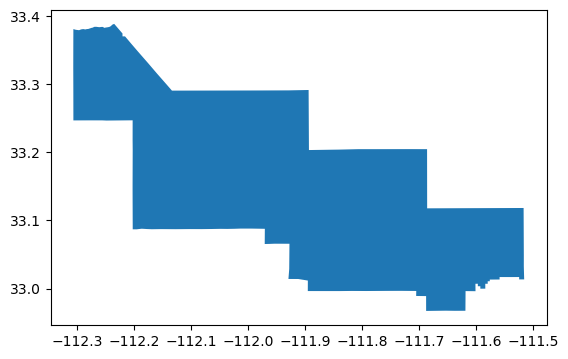

In [32]:
place = "Gila River Indian Community, Arizona, USA"

gila = ox.geocode_to_gdf(place)

gila.plot()
plt.show()

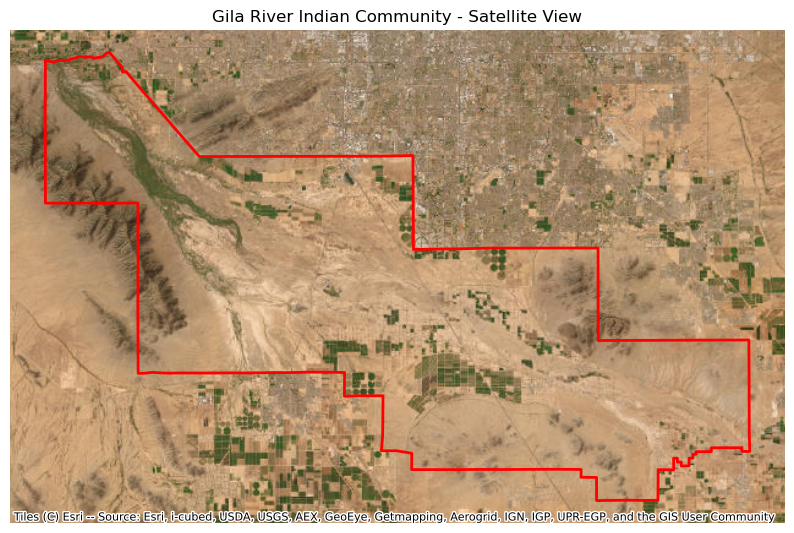

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))

# boundary outline
gila_web.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2
)

# satellite basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)

ax.set_title("Gila River Indian Community - Satellite View")
ax.set_axis_off()

plt.show()

In [36]:
# ----------------------------
# Water features from OpenStreetMap
# ----------------------------

water_tags = {
    "waterway": True,   # rivers, canals, streams
    "natural": "water", # lakes, ponds
    "water": True       # reservoirs
}

water = ox.features_from_place(place, tags=water_tags)

# convert to same projection as your map
water_web = water.to_crs(epsg=3857)

In [37]:
# draw water features in blue
if not water_web.empty:
    water_web.plot(
        ax=ax,
        color="blue",
        alpha=0.6,
        linewidth=1
    )

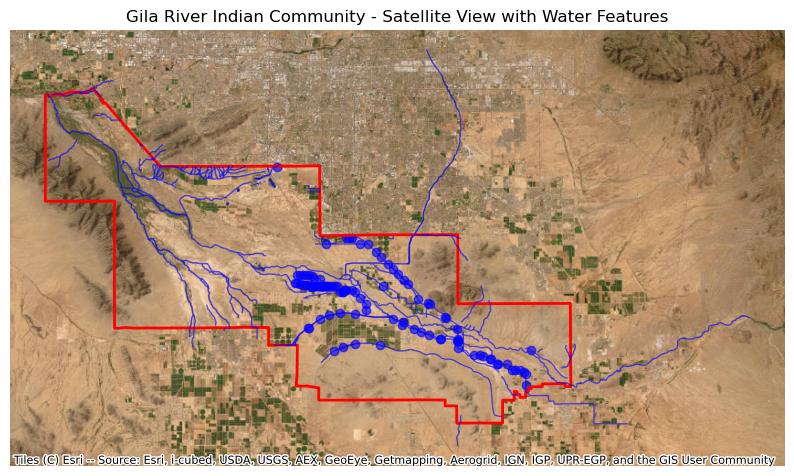

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))

# boundary outline
gila_web.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2
)

# water features (ADD THIS)
water_web.plot(
    ax=ax,
    color="blue",
    alpha=0.6,
    linewidth=1
)

# satellite basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)

ax.set_title("Gila River Indian Community - Satellite View with Water Features")
ax.set_axis_off()

plt.show()

In [40]:
G = ox.graph_from_place(place, network_type="drive")
edges = ox.graph_to_gdfs(G, nodes=False).to_crs(epsg=3857)

edges.plot(
    ax=ax,
    linewidth=0.4,
    color="white",
    alpha=0.7
)

<Axes: title={'center': 'Gila River Indian Community - Satellite View with Water Features'}>

In [41]:
river_tags = {"waterway": "river"}

rivers = ox.features_from_place(place, tags=river_tags)
rivers_web = rivers.to_crs(epsg=3857)

rivers_web.plot(
    ax=ax,
    color="cyan",
    linewidth=2
)

<Axes: title={'center': 'Gila River Indian Community - Satellite View with Water Features'}>

In [42]:
gila_bounds = gila_web.total_bounds  # minx, miny, maxx, maxy

ax.set_xlim(gila_bounds[0], gila_bounds[2])
ax.set_ylim(gila_bounds[1], gila_bounds[3])

(3890936.2734898506, 3946961.9348893478)

In [43]:
ax.text(-12500000, 3900000, "Sacaton", color="white", fontsize=10)

Text(-12500000, 3900000, 'Sacaton')

In [44]:
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    zoom=12
)

<Figure size 640x480 with 0 Axes>

In [45]:
plt.savefig(
    "gila_map_final.png",
    dpi=400,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

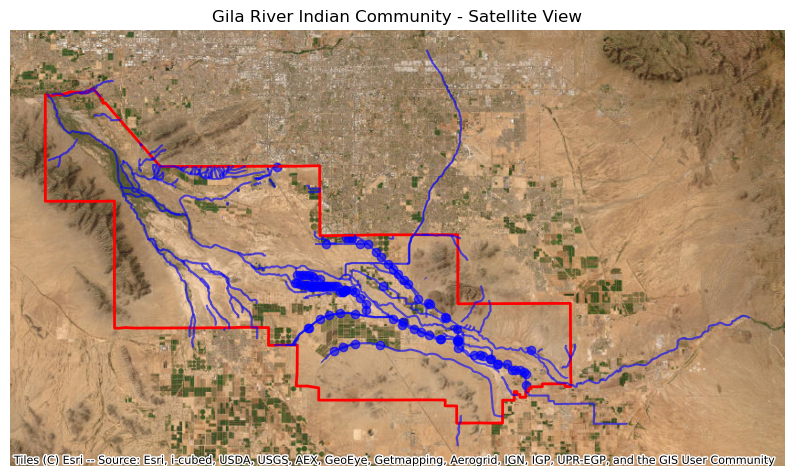

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))

gila_web.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2
)

water_web.plot(
    ax=ax,
    color="blue",
    alpha=0.6
)

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)

ax.set_title("Gila River Indian Community - Satellite View")
ax.set_axis_off()

plt.show()

In [54]:
%store gila_bounds

Stored 'gila_bounds' (ndarray)
